# 01 · Exploratory Data Analysis

**Inputs:** `data/raw/clients.csv`, `data/raw/properties.csv`  
**Output:** `data/processed/cleaned_dataset.csv`

## 1 · Imports

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


## 2 · Load Raw Data

In [33]:
clients    = pd.read_csv('../data/raw/clients.csv')
properties = pd.read_csv('../data/raw/properties.csv')

print('Clients shape   :', clients.shape)
print('Properties shape:', properties.shape)

Clients shape   : (2000, 12)
Properties shape: (10000, 9)


In [34]:
clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [35]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


## 3 · Data Quality Check

In [36]:
print('=== CLIENTS INFO ===')
clients.info()
print('\n=== PROPERTIES INFO ===')
properties.info()

=== CLIENTS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB

=== PROPERTIES INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 

In [37]:
print('=== MISSING VALUES ===')
print('\nClients:')
print(clients.isnull().sum())
print('\nProperties:')
print(properties.isnull().sum())

=== MISSING VALUES ===

Clients:
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

Properties:
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64


In [38]:
print('=== DUPLICATE ROWS ===')
print('Clients duplicates   :', clients.duplicated().sum())
print('Properties duplicates:', properties.duplicated().sum())

# Remove duplicates
clients    = clients.drop_duplicates()
properties = properties.drop_duplicates()

print('\nAfter dedup — Clients:', clients.shape, '| Properties:', properties.shape)

=== DUPLICATE ROWS ===
Clients duplicates   : 0
Properties duplicates: 0

After dedup — Clients: (2000, 12) | Properties: (10000, 9)


## 4 · Data Type Conversions & Cleaning

In [39]:
# Parse mixed-format dates safely
clients['date_of_birth'] = pd.to_datetime(
    clients['date_of_birth'],
    format='mixed',
    errors='coerce'
)

properties['transaction_date'] = pd.to_datetime(
    properties['transaction_date'],
    format='mixed',
    errors='coerce'
)

print('Date parsing done')
print('Missing DOB          :', clients['date_of_birth'].isnull().sum())
print('Missing trans. date  :', properties['transaction_date'].isnull().sum())

Date parsing done
Missing DOB          : 0
Missing trans. date  : 0


In [40]:
# Clean sale_price: remove $ and commas, cast to float
properties['sale_price'] = (
    properties['sale_price']
    .replace('[\$,]', '', regex=True)
    .astype(float)
)

print('sale_price cleaned')
print(properties['sale_price'].describe().round(2))

sale_price cleaned
count     10000.00
mean     344374.68
std      131563.10
min       97402.80
25%      232173.64
50%      330680.84
75%      448852.58
max      736652.27
Name: sale_price, dtype: float64


In [41]:
# Drop rows where client_ref is null (unlinked properties)
properties = properties.dropna(subset=['client_ref'])
print('Properties after dropping null client_ref:', properties.shape)

Properties after dropping null client_ref: (7305, 9)


In [42]:
# Calculate age from date_of_birth
current_year = datetime.now().year
clients['age'] = current_year - clients['date_of_birth'].dt.year

# Sanity check
print('Age range:', clients['age'].min(), '–', clients['age'].max())
clients[['date_of_birth', 'age']].head()

Age range: 26 – 95


,date_of_birth,age
0,1968-05-11,58
1,1962-11-26,64
2,1959-04-07,67
3,1959-11-25,67
4,1976-02-28,50


## 5 · Merge Clients & Properties

In [43]:
df = pd.merge(
    clients,
    properties,
    left_on='client_id',
    right_on='client_ref',
    how='inner'
)

# Drop redundant join key
df = df.drop(columns=['client_ref'])

print('Merged shape:', df.shape)
df.head()

Merged shape: (7305, 21)


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status
0,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,90343,9,2024-10-01,Apartment,40,1090.32,351419.29,Sold
1,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,4051,4,2024-12-01,Apartment,51,1608.84,496266.41,Sold
2,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,150099,15,2025-05-01,Apartment,15,522.71,175599.90,Sold
3,C0001,Individual,Kareem,Liu,1968-05-11,F,USA,California,Home,4,Yes,Website,58,30432,3,2025-12-01,Apartment,50,713.67,223479.12,Sold
4,C0002,Individual,Trystan,Oconnor,1962-11-26,M,USA,California,Home,1,No,Website,64,150044,15,2024-01-01,Apartment,6,938.57,299245.20,Sold


In [44]:
print('Missing values in merged dataset:')
print(df.isnull().sum())

# Drop any remaining nulls
df = df.dropna()
print('\nFinal shape after dropna:', df.shape)

Missing values in merged dataset:
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
age                    0
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
dtype: int64

Final shape after dropna: (7305, 21)


In [45]:
from scipy import stats

z_scores = np.abs(stats.zscore(df[['sale_price', 'floor_area_sqft']]))
df = df[(z_scores < 3).all(axis=1)]
print('Shape after outlier removal:', df.shape)

Shape after outlier removal: (7305, 21)


## 6 · Feature Binning

In [46]:
# Age group
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Young (≤30)', 'Mid (31–45)', 'Senior (46–60)', 'Mature (60+)']
)

# Price segment
df['price_segment'] = pd.cut(
    df['sale_price'],
    bins=[0, 200000, 500000, 1000000, 10000000],
    labels=['Budget', 'Mid', 'Premium', 'Luxury']
)

# Size segment
df['size_segment'] = pd.cut(
    df['floor_area_sqft'],
    bins=[0, 800, 1500, 2500, 10000],
    labels=['Small', 'Medium', 'Large', 'Very Large']
)

print('Binning done')
df[['age', 'age_group', 'sale_price', 'price_segment', 'floor_area_sqft', 'size_segment']].head()

Binning done


,age,age_group,sale_price,price_segment,floor_area_sqft,size_segment
0,58,Senior (46–60),351419.29,Mid,1090.32,Medium
1,58,Senior (46–60),496266.41,Mid,1608.84,Large
2,58,Senior (46–60),175599.90,Budget,522.71,Small
3,58,Senior (46–60),223479.12,Mid,713.67,Small
4,64,Mature (60+),299245.20,Mid,938.57,Medium


## 7 · Exploratory Data Analysis

### 7a · Univariate Analysis — Numeric

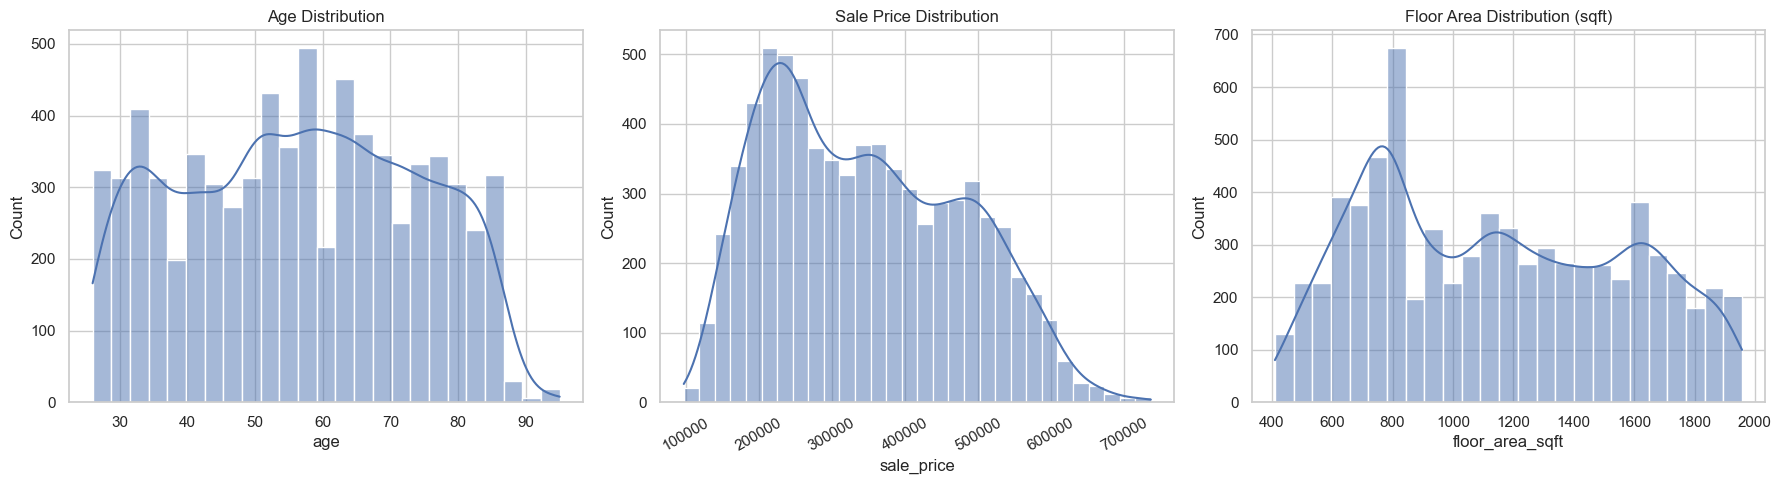

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='age', bins=25, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(data=df, x='sale_price', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Sale Price Distribution')
axes[1].xaxis.set_tick_params(rotation=30)

sns.histplot(data=df, x='floor_area_sqft', bins=25, kde=True, ax=axes[2])
axes[2].set_title('Floor Area Distribution (sqft)')

plt.tight_layout()
plt.show()

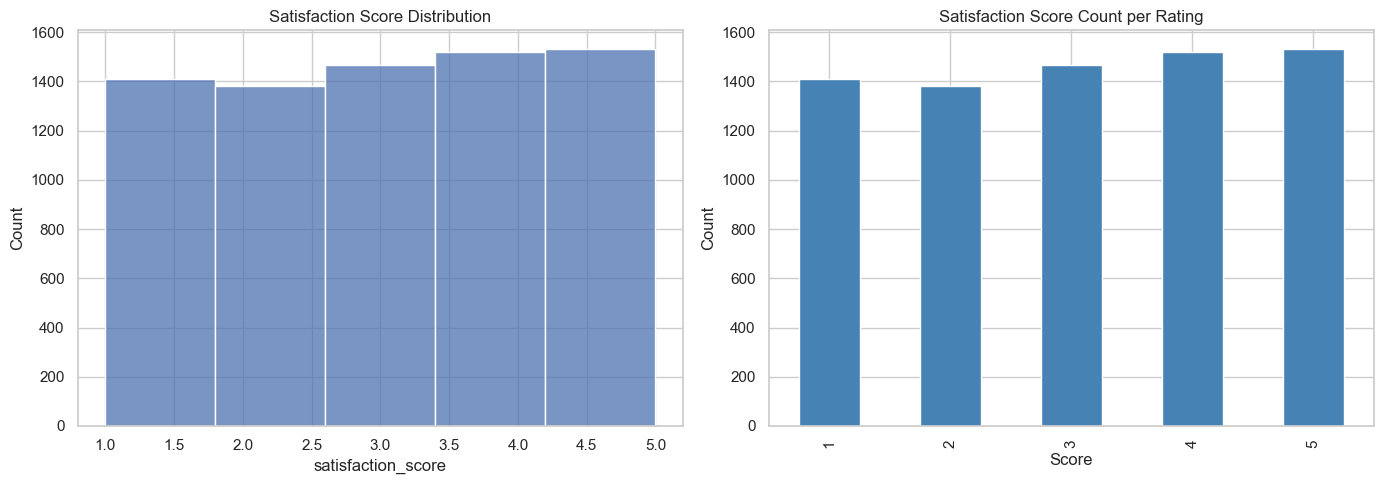

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='satisfaction_score', bins=5, kde=False, ax=axes[0])
axes[0].set_title('Satisfaction Score Distribution')

df['satisfaction_score'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Satisfaction Score Count per Rating')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 7b · Univariate Analysis — Categorical

C:\Users\sanch\AppData\Local\Temp\ipykernel_8488\3449898559.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\sanch\AppData\Local\Temp\ipykernel_8488\3449898559.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\sanch\AppData\Local\Temp\ipykernel_8488\3449898559.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\sanch\AppData\Local\Temp\ipykernel_8488\3449898559.py:8: FutureW

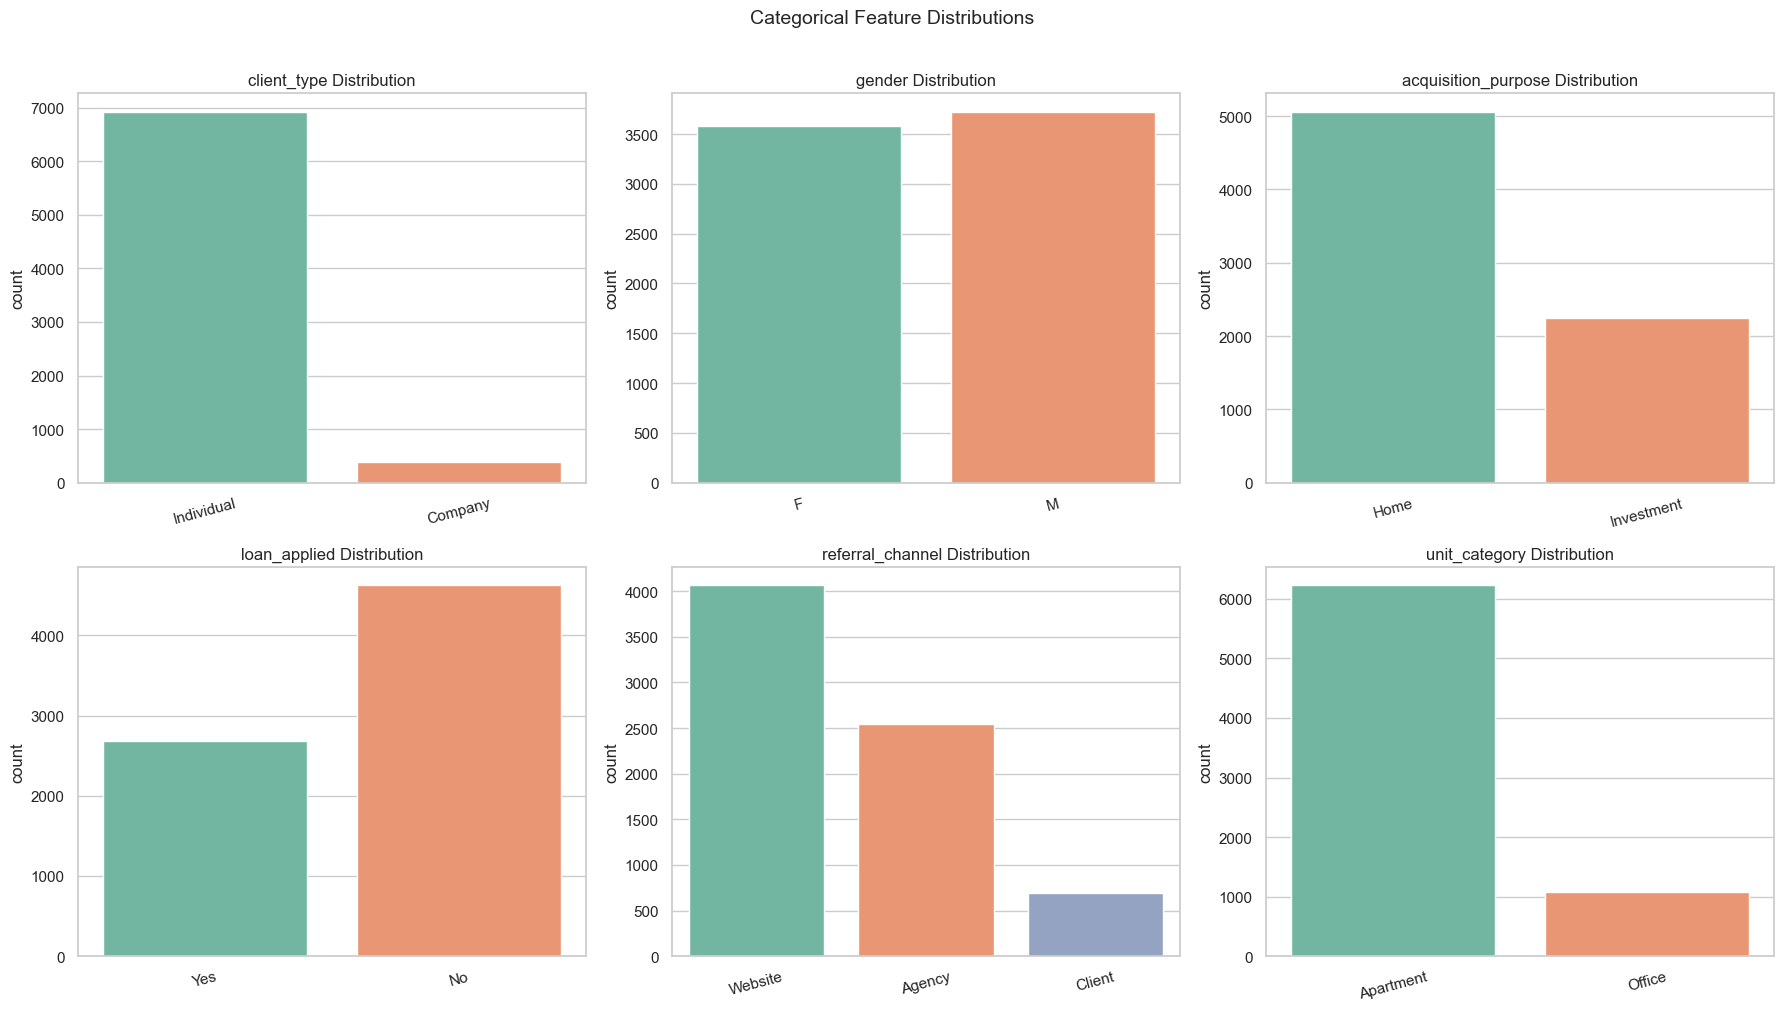

In [49]:
cat_cols = ['client_type', 'gender', 'acquisition_purpose', 'loan_applied',
            'referral_channel', 'unit_category']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 7c · Geographic Analysis

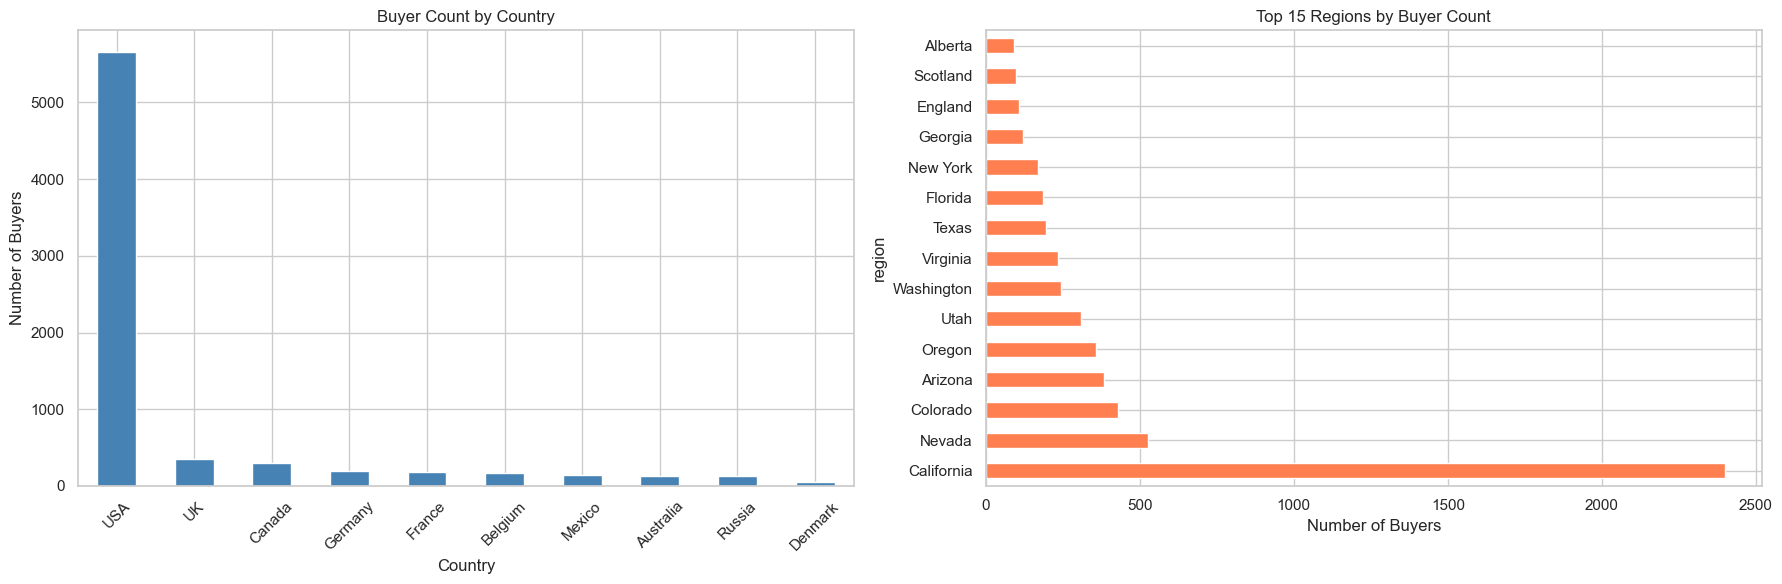

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top countries
country_counts = df['country'].value_counts()
country_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Buyer Count by Country')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Number of Buyers')
axes[0].tick_params(axis='x', rotation=45)

# Top 15 regions
region_counts = df['region'].value_counts().head(15)
region_counts.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 15 Regions by Buyer Count')
axes[1].set_xlabel('Number of Buyers')

plt.tight_layout()
plt.show()

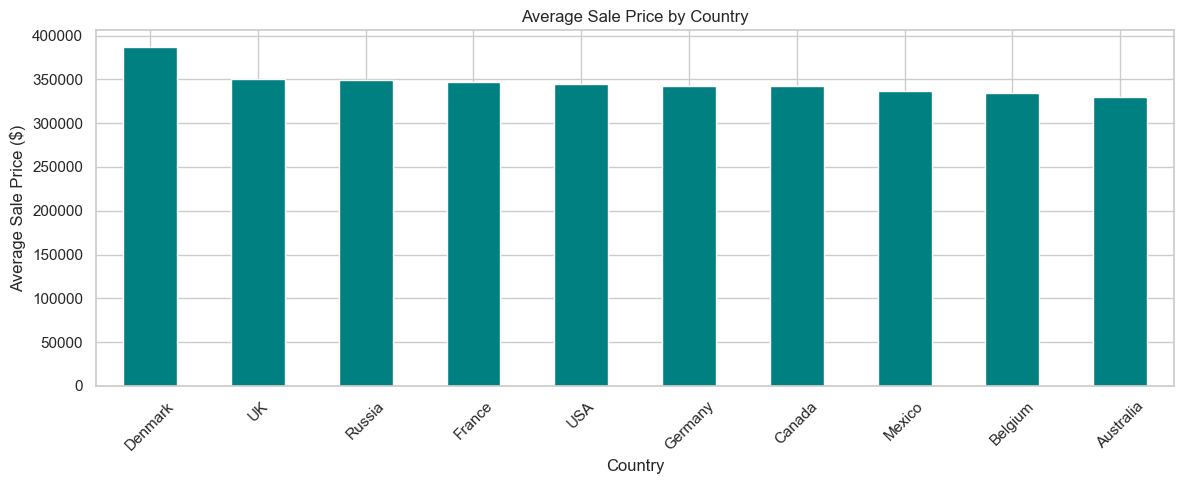

In [51]:
# Average sale price by country
avg_price_country = df.groupby('country')['sale_price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
avg_price_country.plot(kind='bar', color='teal')
plt.title('Average Sale Price by Country')
plt.ylabel('Average Sale Price ($)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7d · Cross Analysis — Buyer Behaviour

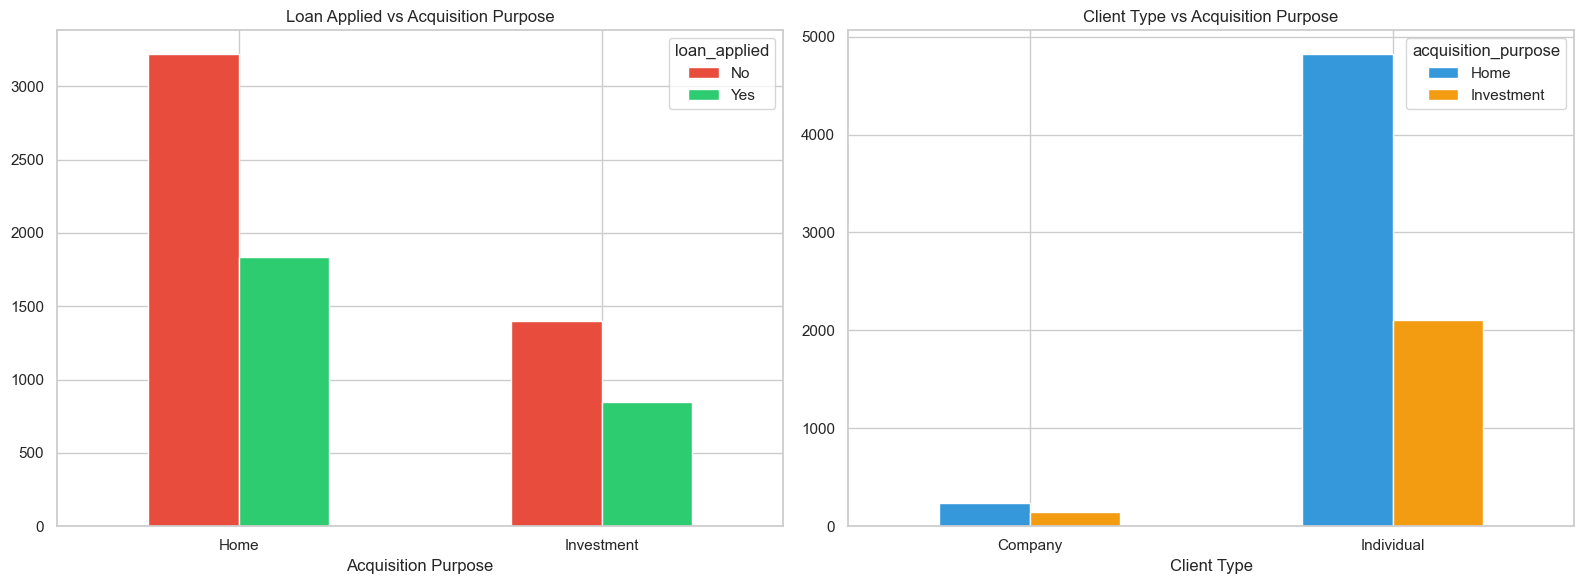

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loan applied vs acquisition purpose
loan_purpose = pd.crosstab(df['acquisition_purpose'], df['loan_applied'])
loan_purpose.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Loan Applied vs Acquisition Purpose')
axes[0].set_xlabel('Acquisition Purpose')
axes[0].tick_params(axis='x', rotation=0)

# Client type vs acquisition purpose
ct_purpose = pd.crosstab(df['client_type'], df['acquisition_purpose'])
ct_purpose.plot(kind='bar', ax=axes[1], color=['#3498db', '#f39c12'])
axes[1].set_title('Client Type vs Acquisition Purpose')
axes[1].set_xlabel('Client Type')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

C:\Users\sanch\AppData\Local\Temp\ipykernel_8488\3750316576.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='client_type', y='sale_price', ax=axes[0], palette='Set2')
C:\Users\sanch\AppData\Local\Temp\ipykernel_8488\3750316576.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='acquisition_purpose', y='sale_price', ax=axes[1], palette='Set3')


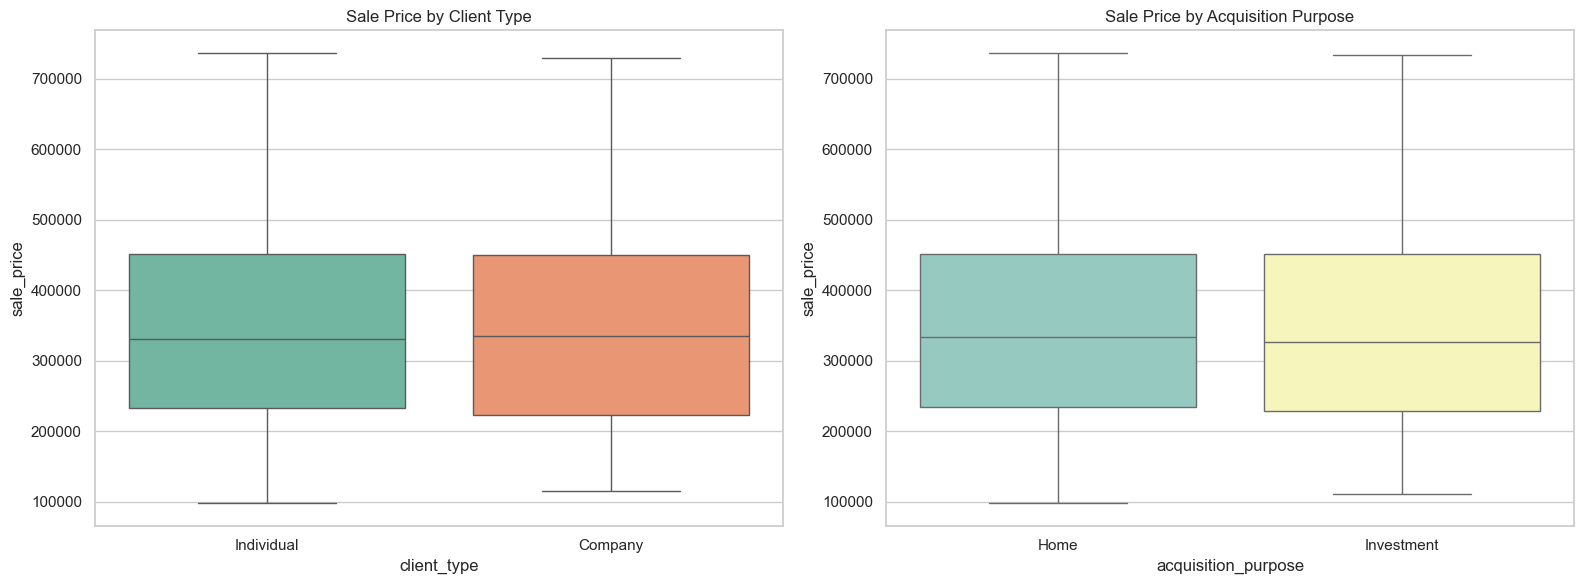

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sale price by client type
sns.boxplot(data=df, x='client_type', y='sale_price', ax=axes[0], palette='Set2')
axes[0].set_title('Sale Price by Client Type')

# Sale price by acquisition purpose
sns.boxplot(data=df, x='acquisition_purpose', y='sale_price', ax=axes[1], palette='Set3')
axes[1].set_title('Sale Price by Acquisition Purpose')

plt.tight_layout()
plt.show()

C:\Users\sanch\AppData\Local\Temp\ipykernel_8488\1270691528.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='referral_channel', ax=axes[0], palette='pastel')


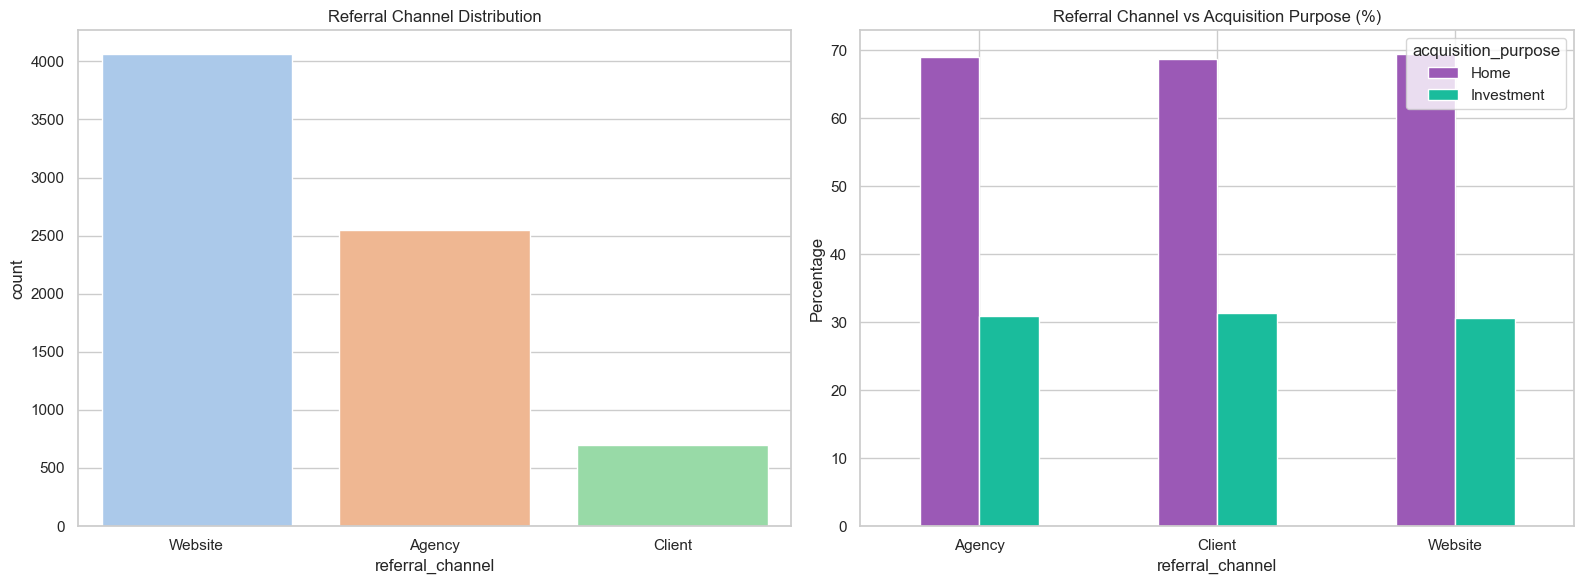

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Referral channel distribution
sns.countplot(data=df, x='referral_channel', ax=axes[0], palette='pastel')
axes[0].set_title('Referral Channel Distribution')

# Referral channel vs acquisition purpose
ref_purpose = pd.crosstab(df['referral_channel'], df['acquisition_purpose'], normalize='index') * 100
ref_purpose.plot(kind='bar', ax=axes[1], color=['#9b59b6', '#1abc9c'])
axes[1].set_title('Referral Channel vs Acquisition Purpose (%)')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

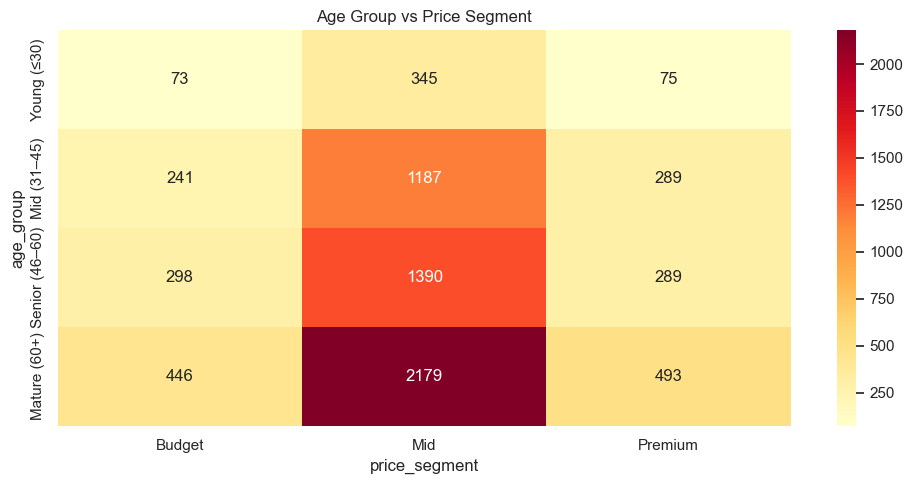

In [55]:
# Age group vs price segment heatmap
age_price = pd.crosstab(df['age_group'], df['price_segment'])

plt.figure(figsize=(10, 5))
sns.heatmap(age_price, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Age Group vs Price Segment')
plt.tight_layout()
plt.show()

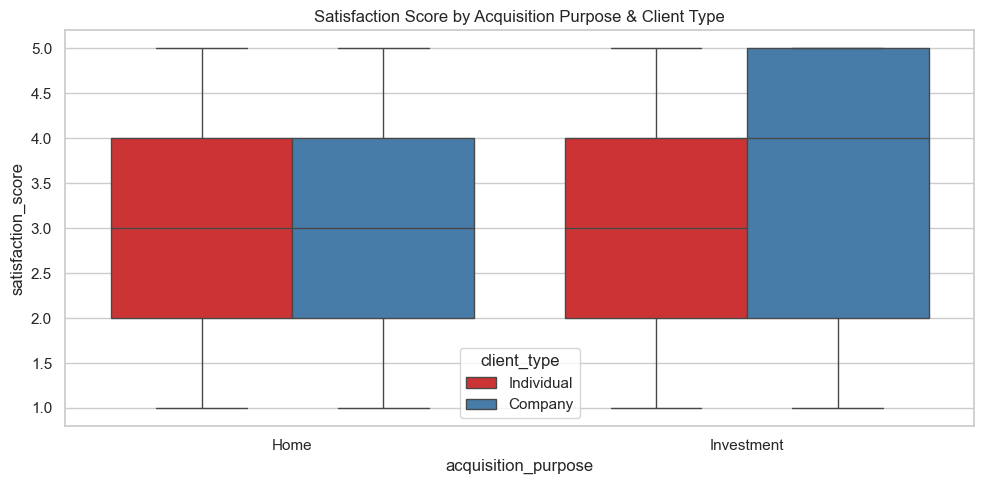

In [56]:
# Satisfaction score by acquisition purpose
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='acquisition_purpose', y='satisfaction_score', hue='client_type', palette='Set1')
plt.title('Satisfaction Score by Acquisition Purpose & Client Type')
plt.tight_layout()
plt.show()

### 7e · Correlation Heatmap

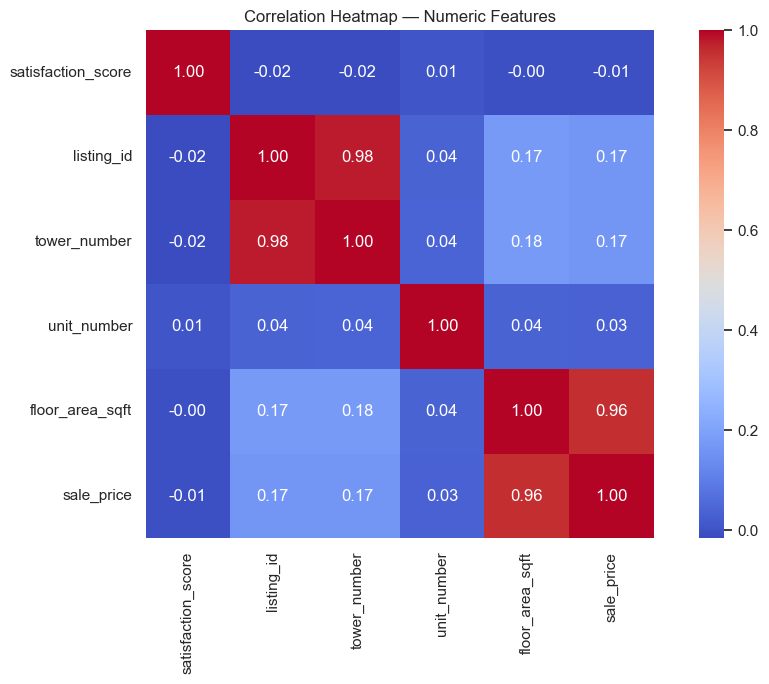

In [57]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True
)
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

### 7f · Binned Feature Distributions

C:\Users\sanch\AppData\Local\Temp\ipykernel_8488\3424634136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='age_group', ax=axes[0], palette='Blues_d')
C:\Users\sanch\AppData\Local\Temp\ipykernel_8488\3424634136.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='price_segment', ax=axes[1], palette='Oranges_d')
C:\Users\sanch\AppData\Local\Temp\ipykernel_8488\3424634136.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='size_segment', ax=axes[2], palette='Greens_d')


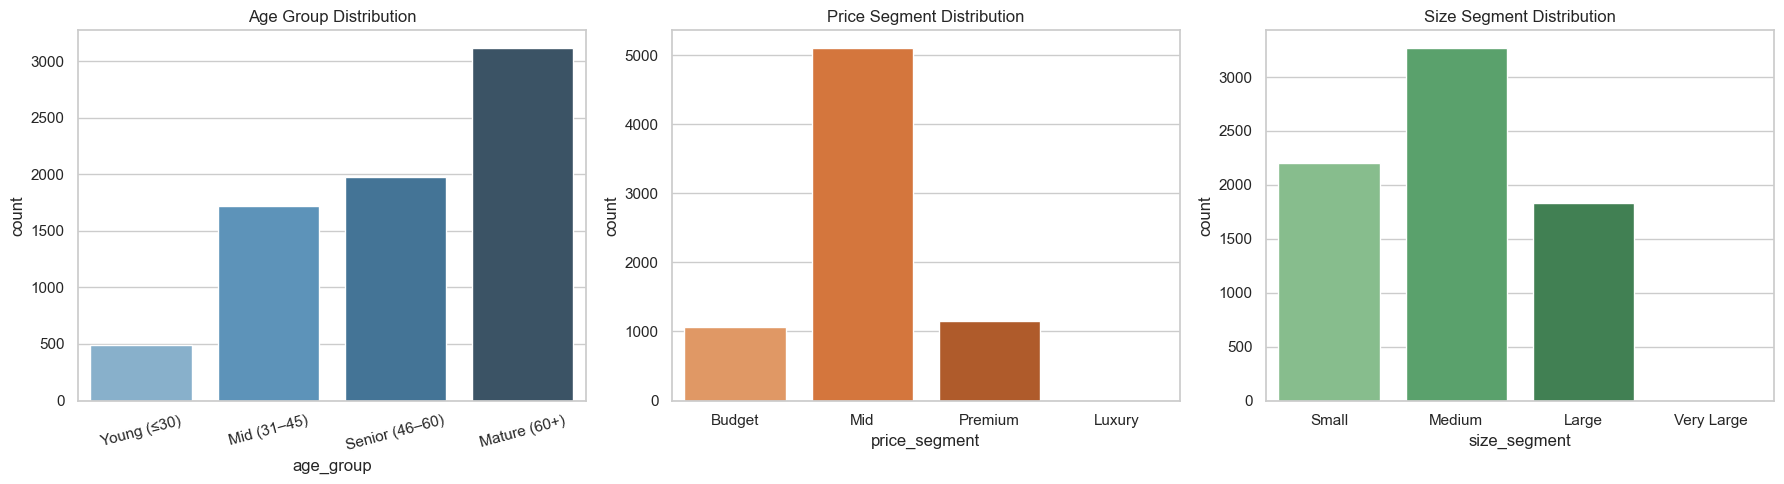

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='age_group', ax=axes[0], palette='Blues_d')
axes[0].set_title('Age Group Distribution')
axes[0].tick_params(axis='x', rotation=15)

sns.countplot(data=df, x='price_segment', ax=axes[1], palette='Oranges_d')
axes[1].set_title('Price Segment Distribution')

sns.countplot(data=df, x='size_segment', ax=axes[2], palette='Greens_d')
axes[2].set_title('Size Segment Distribution')

plt.tight_layout()
plt.show()

## 8 · Summary Statistics

In [59]:
print('=== KEY STATISTICS ===')
print(f'Total records        : {len(df):,}')
print(f'Unique buyers        : {df["client_id"].nunique():,}')
print(f'Countries            : {df["country"].nunique()}')
print(f'Regions              : {df["region"].nunique()}')
print(f'Average age          : {df["age"].mean():.1f} years')
print(f'Average sale price   : ${df["sale_price"].mean():,.0f}')
print(f'Average floor area   : {df["floor_area_sqft"].mean():,.0f} sqft')
print(f'Avg satisfaction     : {df["satisfaction_score"].mean():.2f} / 5')
print(f'Loan applied (%)     : {(df["loan_applied"]=="Yes").mean()*100:.1f}%')
print(f'Investment purpose(%): {(df["acquisition_purpose"]=="Investment").mean()*100:.1f}%')

=== KEY STATISTICS ===
Total records        : 7,305
Unique buyers        : 2,000
Countries            : 10
Regions              : 57
Average age          : 56.4 years
Average sale price   : $345,072
Average floor area   : 1,141 sqft
Avg satisfaction     : 3.05 / 5
Loan applied (%)     : 36.7%
Investment purpose(%): 30.8%


In [60]:
df.describe(include='all').round(2)

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,age_group,price_segment,size_segment
count,7305,7305,7305,7305,7305,7305,7305,7305,7305,7305.00,7305,7305,7305.00,7305.00,7305.00,7305,7305,7305.00,7305.00,7305.00,7305,7305,7305,7305
unique,2000,2,337,224,NaN,2,10,57,2,NaN,2,3,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,1,4,3,3
top,C0005,Individual,Carl,Co,NaN,M,USA,California,Home,NaN,No,Website,NaN,NaN,NaN,NaN,Apartment,NaN,NaN,NaN,Sold,Mature (60+),Mid,Medium
freq,13,6924,87,381,NaN,3723,5656,2399,5058,NaN,4621,4063,NaN,NaN,NaN,NaN,6225,NaN,NaN,NaN,7305,3118,5101,3269
mean,NaN,NaN,NaN,NaN,1970-01-25 03:48:04.435318275,NaN,NaN,NaN,NaN,3.05,NaN,NaN,56.43,103366.96,10.36,2024-11-06 15:55:16.139630336,NaN,29.04,1141.15,345072.00,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1931-02-13 00:00:00,NaN,NaN,NaN,NaN,1.00,NaN,NaN,26.00,1002.00,1.00,2024-01-01 00:00:00,NaN,1.00,410.71,97402.80,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,1955-10-16 00:00:00,NaN,NaN,NaN,NaN,2.00,NaN,NaN,42.00,50360.00,5.00,2024-05-01 00:00:00,NaN,15.00,782.15,232448.63,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,1969-07-15 00:00:00,NaN,NaN,NaN,NaN,3.00,NaN,NaN,57.00,100384.00,10.00,2024-10-01 00:00:00,NaN,29.00,1110.88,330997.32,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,1984-06-23 00:00:00,NaN,NaN,NaN,NaN,4.00,NaN,NaN,71.00,150404.00,15.00,2025-05-01 00:00:00,NaN,43.00,1501.64,451237.67,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,2000-12-19 00:00:00,NaN,NaN,NaN,NaN,5.00,NaN,NaN,95.00,990000.00,20.00,2025-12-01 00:00:00,NaN,70.00,1957.16,736652.27,NaN,NaN,NaN,NaN


## 9 · Save Cleaned Dataset

In [61]:
df.to_csv('../data/processed/cleaned_dataset.csv', index=False)
print('cleaned_dataset.csv saved successfully')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

cleaned_dataset.csv saved successfully
Shape: (7305, 24)
Columns: ['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth', 'gender', 'country', 'region', 'acquisition_purpose', 'satisfaction_score', 'loan_applied', 'referral_channel', 'age', 'listing_id', 'tower_number', 'transaction_date', 'unit_category', 'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status', 'age_group', 'price_segment', 'size_segment']
